# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [269]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [328]:
pima_df = pd.read_csv("pima-indians-diabetes.data")

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

In [329]:
colnames = ['preg', 'plas', 'bp', 'skin', 'ins', 'mass', 'pedi', 'age', 'class']

pima_df = pd.read_csv("pima-indians-diabetes.data",names=colnames)

In [330]:
pima_df.head(10)

,preg,plas,bp,skin,ins,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q2. Print 10 samples from the dataset

In [331]:
pima_df.head(10)

,preg,plas,bp,skin,ins,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [332]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
plas     768 non-null int64
bp       768 non-null int64
skin     768 non-null int64
ins      768 non-null int64
mass     768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Q3 Print the datatypes of each column and the shape of the dataset 

In [334]:
pima_df.dtypes

preg       int64
plas       int64
bp         int64
skin       int64
ins        int64
mass     float64
pedi     float64
age        int64
class      int64
dtype: object

In [335]:
pima_df.shape

(768, 9)

In [336]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
plas     768 non-null int64
bp       768 non-null int64
skin     768 non-null int64
ins      768 non-null int64
mass     768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


In [337]:
pima_df.describe()

,preg,plas,bp,skin,ins,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [339]:
plas_median = np.median(pima_df['plas'])
bp_median = np.median(pima_df['bp'])
skin_median = np.median(pima_df['skin'])
ins_median  = np.median(pima_df['ins'])
mass_median = np.median(pima_df['mass'])

In [340]:
pima_df['plas']= pima_df['plas'].replace(to_replace=0,value=plas_median)
pima_df['bp'] = pima_df['bp'].replace(to_replace=0,value=bp_median)
pima_df['skin'] = pima_df['skin'].replace(to_replace=0,value=skin_median)
pima_df['ins'] = pima_df['ins'].replace(to_replace=0,value=ins_median)
pima_df['mass'] = pima_df['mass'].replace(to_replace=0,value=mass_median)

# Q5 Print the descriptive statistics of each & every column using describe() function

In [341]:
pima_df.describe()

,preg,plas,bp,skin,ins,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002CA3C925470>,
      dtype=object)

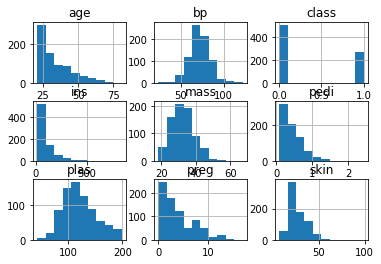

In [342]:
pima_df.hist()

class
0    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
1    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
dtype: object

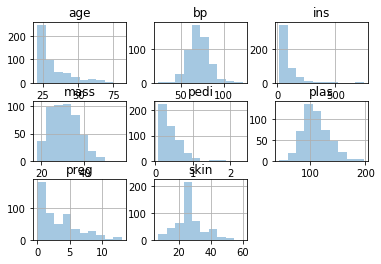

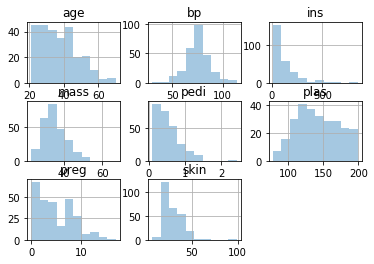

In [343]:
pima_df.groupby('class').hist(alpha=0.4)

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


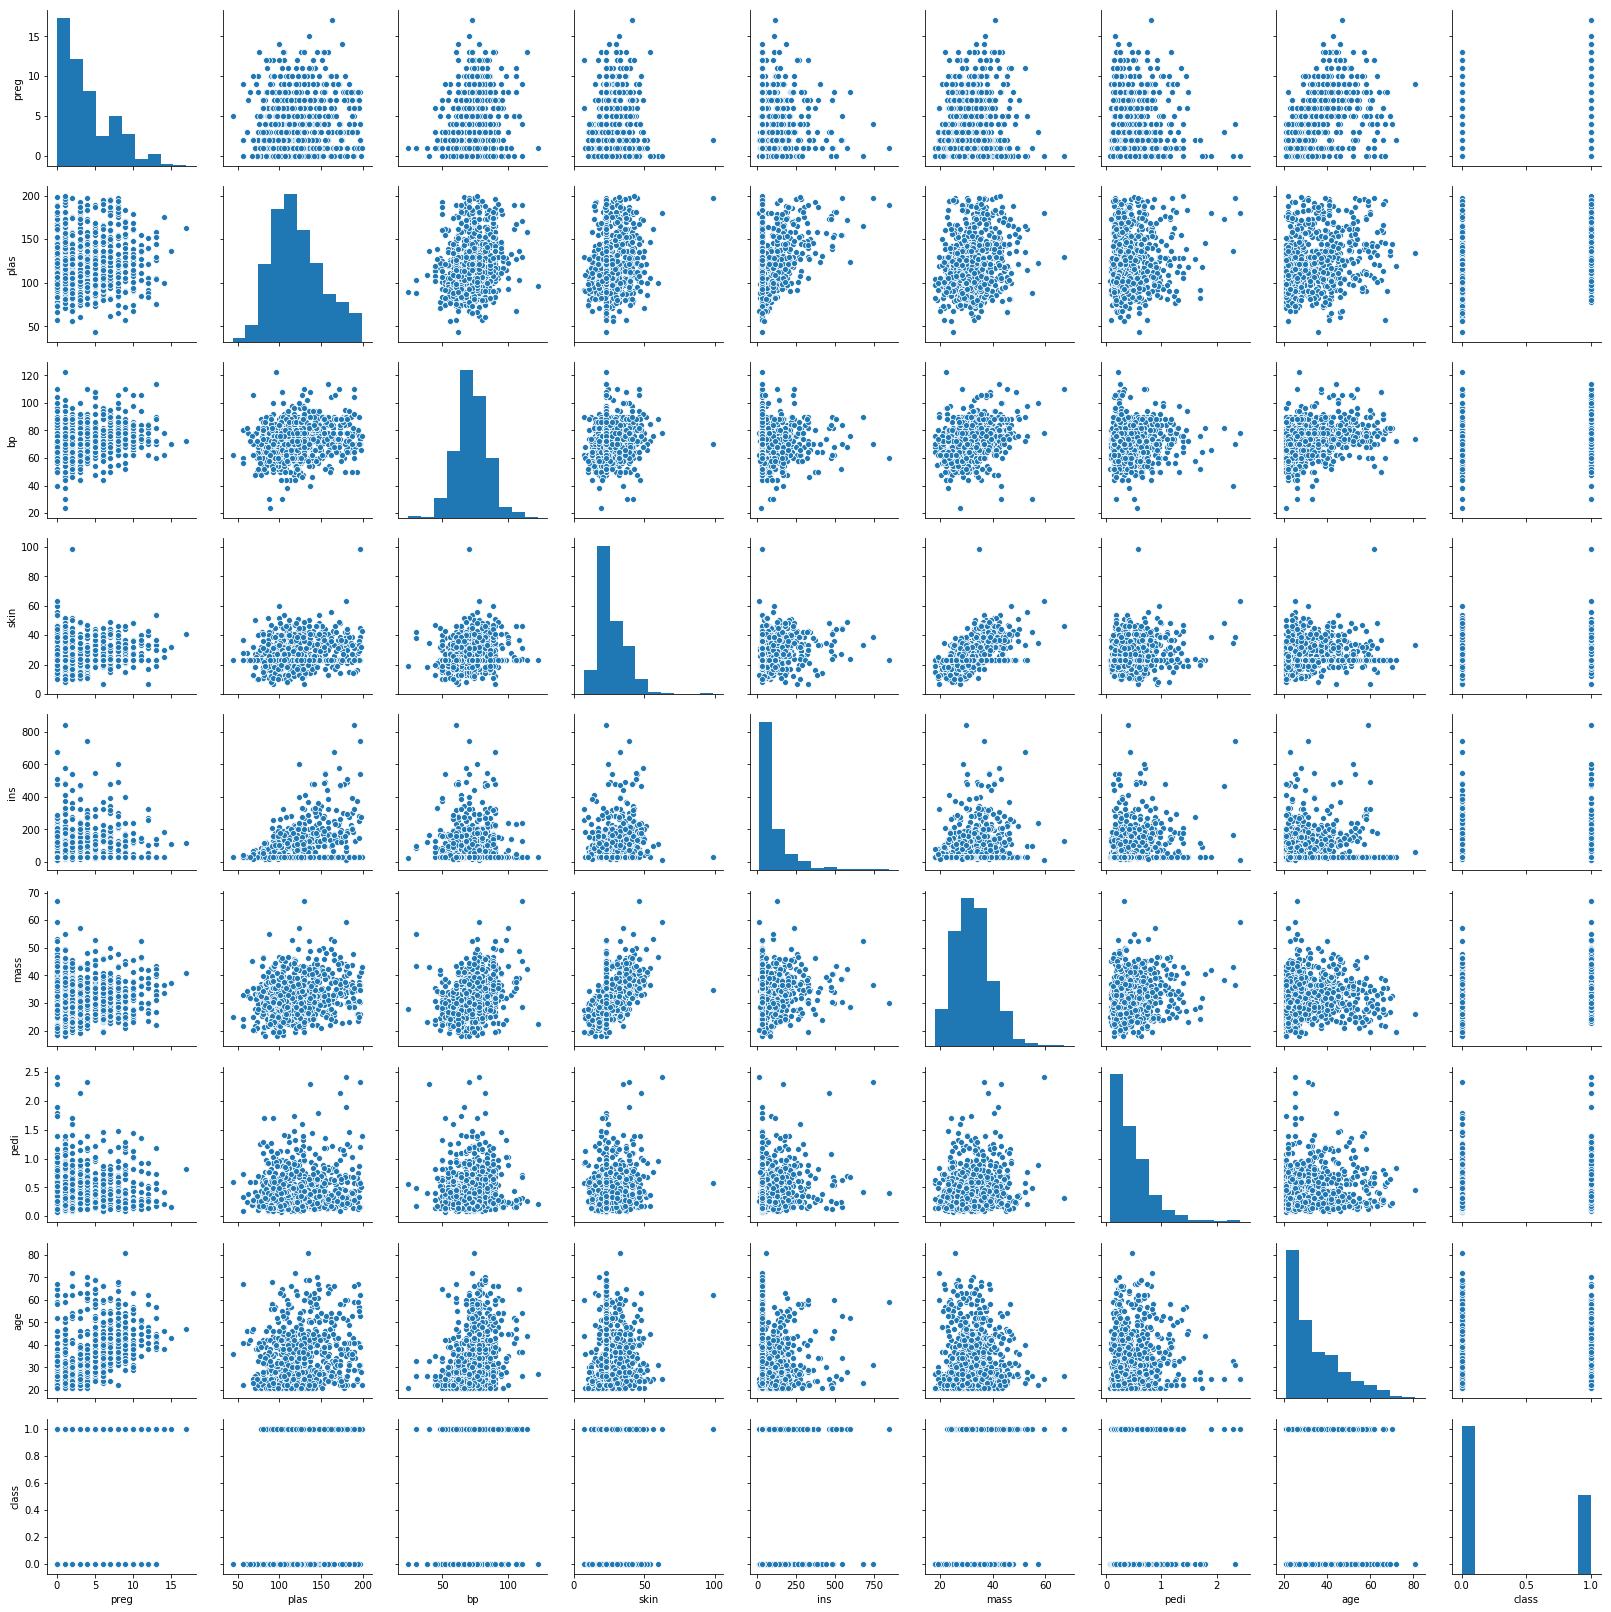

In [344]:
sns.pairplot(pima_df)

In [346]:
#coorelation betweent the variables
correlation = pima_df.corr()

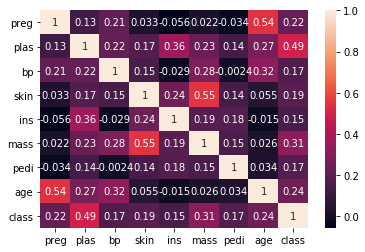

In [347]:
import seaborn
seaborn.heatmap(correlation,annot=True)

In [348]:
# Some of the attributes look like they may have an exponential distribution (preg, test, pedi, age).
# Age should probably have a normal distribution, the constraints on the data collection may have skewed the distribution.
# There is no obvious relationship between age and onset of diabetes.
# There is no obvious relationship between pedi function and onset of diabetes.

Using the plot - infer the relationship between different variables

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [349]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

In [350]:
# taking 70:30 training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [351]:
from sklearn.tree import DecisionTreeClassifier

model1 = DecisionTreeClassifier(random_state=0)

In [352]:
#Perform Grid Search Method to find the optimal max_depth size


from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(model1,parameter,cv=3)
GS.fit(X,y)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [353]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 4}

In [354]:
#Got a max depth of 4 using grid search using the same and building the model again

modelDT=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)


In [355]:
modelDT.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [356]:
y_pred = modelDT.predict(X_test)

# Q10 Print the accuracy of the model & print the confusion matrix 

In [358]:
accuracy = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Decision tree model:",accuracy)

Accuracy score of Decision tree model: 0.7445887445887446


Print the feature importance of the decision model - Optional

In [359]:
#Confusion matrix
cm=metrics.confusion_matrix(y_test,y_pred)
print(cm)

[[127  30]
 [ 29  45]]


# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [360]:
from sklearn.ensemble import RandomForestClassifier
modelRF1 = RandomForestClassifier(random_state=0)

In [362]:
#Perform Grid Search Method on Random forest to find the optimal estimators

from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':np.arange(1,100),'criterion' : ['entropy','gini']}
GS1=GridSearchCV(modelRF1,parameter)
GS1.fit(X,y)

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 1,  2, ..., 98, 99]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [364]:
GS1.best_params_

{'criterion': 'entropy', 'n_estimators': 65}

In [365]:
modelRF2 = RandomForestClassifier(n_estimators=65,criterion='entropy',random_state=0)

In [366]:
modelRF2.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=65, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [367]:
y_pred = modelRF2.predict(X_test)

In [368]:
rf_accuracy = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Random forest model:",rf_accuracy)

Accuracy score of Random forest model: 0.7835497835497836


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [370]:
from sklearn.ensemble import AdaBoostClassifier
boost_rf=AdaBoostClassifier(base_estimator=modelRF2,random_state=0)

In [371]:
#Perform Grid Search Method on Boosted Random forest to find the optimal estimators

from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':np.arange(50,100)}
GS2=GridSearchCV(boost_rf,parameter)
GS2.fit(X,y)

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=AdaBoostClassifier(algorithm='SAMME.R',
          base_estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            ...state=0, verbose=0, warm_start=False),
          learning_rate=1.0, n_estimators=50, random_state=0),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [372]:
GS2.best_params_

{'n_estimators': 50}

In [373]:
boost_rf1=AdaBoostClassifier(base_estimator=modelRF2,n_estimators=65,random_state=0)

In [374]:
boost_rf1.fit(X_train,y_train)

AdaBoostClassifier(algorithm='SAMME.R',
          base_estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=65, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
          learning_rate=1.0, n_estimators=65, random_state=0)

In [375]:
y_pred = boost_rf1.predict(X_test)

In [376]:
rfboost_accuracy1 = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Boosted Random forest model:",rfboost_accuracy1)

Accuracy score of Boosted Random forest model: 0.7748917748917749


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [304]:
from sklearn.ensemble import BaggingClassifier
bag_dt=BaggingClassifier(random_state=0)

In [377]:
#Perform Grid Search Method on BAgged Decision Tree to find the optimal estimators

parameter={'n_estimators':np.arange(1,100)}
GS3=GridSearchCV(bag_dt,parameter)
GS3.fit(X,y)

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=BaggingClassifier(base_estimator=None, bootstrap=True,
         bootstrap_features=False, max_features=1.0, max_samples=1.0,
         n_estimators=10, n_jobs=None, oob_score=False, random_state=0,
         verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 1,  2, ..., 98, 99])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [378]:
GS3.best_params_

{'n_estimators': 97}

In [391]:
bag_dt1=BaggingClassifier(n_estimators=97,random_state=0)

In [392]:
bag_dt1.fit(X_train,y_train)

BaggingClassifier(base_estimator=None, bootstrap=True,
         bootstrap_features=False, max_features=1.0, max_samples=1.0,
         n_estimators=97, n_jobs=None, oob_score=False, random_state=0,
         verbose=0, warm_start=False)

In [393]:
y_pred = bag_dt1.predict(X_test)

In [394]:
bagdt_accuracy = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Bagged DT model:",bagdt_accuracy)

Accuracy score of Bagged DT model: 0.8008658008658008


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [395]:
from sklearn.ensemble import GradientBoostingClassifier
gboost = GradientBoostingClassifier(random_state=0)

In [397]:
gboost.fit(X_train,y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=100,
              n_iter_no_change=None, presort='auto', random_state=0,
              subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False)

In [398]:
y_pred = gboost.predict(X_test)

In [399]:
gboost_accuracy1 = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Gradient boost:",gboost_accuracy1)

Accuracy score of Gradient boost: 0.7705627705627706


In [400]:
parameter={'n_estimators':np.arange(1,100)}
GS4=GridSearchCV(gboost,parameter)
GS4.fit(X,y)

C:\Users\muzzammil\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_sampl...      subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 1,  2, ..., 98, 99])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [401]:
GS4.best_params_

{'n_estimators': 46}

In [402]:
gboost1 = GradientBoostingClassifier(n_estimators=46,random_state=0)

In [403]:
gboost1.fit(X_train,y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=46,
              n_iter_no_change=None, presort='auto', random_state=0,
              subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False)

In [404]:
y_pred = gboost1.predict(X_test)

In [405]:
gboost_accuracy = metrics.accuracy_score(y_test,y_pred)
print("Accuracy score of Gradient boost:",gboost_accuracy)

Accuracy score of Gradient boost: 0.7748917748917749


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [406]:
#Trying to do a comparison on the modules to pick the best one based on avaerage scores.
#Plotted the model scores as a box plot for beteer represntation

models = []
models.append(('DT',modelDT))
models.append(('RF',modelRF2))
models.append(('AdaBoost RF',boost_rf1))
models.append(('Bagged DT',bag_dt1))
models.append(('GB',gboost1))

DT: 0.738281 (0.001312)
RF: 0.768229 (0.000329)
AdaBoost RF: 0.752604 (0.000675)
Bagged DT: 0.764323 (0.000756)
GB: 0.765625 (0.000621)


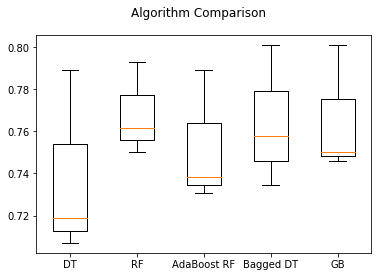

In [407]:
from sklearn import model_selection
from sklearn.model_selection import KFold,cross_val_score
# evaluate each model in turn
results = []
names = []
for name, model in models:
	kfold = model_selection.KFold(n_splits=3,random_state=0)
	cv_results = model_selection.cross_val_score(model, X,y,cv=kfold)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), np.var(cv_results))
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()